# **IEEE-CIS Fraud Detection Dataset**

Contexto de negocio: El objetivo es identificar transacciones fraudulentas en línea para evitar pérdidas millonarias a las empresas de procesamiento de pagos, sin afectar la experiencia de los usuarios legítimos.

**Objetivo de predicción:** Determinar si una transacción es fraude o no (la variable objetivo suele ser isFraud con valores 0 o 1). Por lo tanto, este es un problema de Clasificación Binaria.

https://www.kaggle.com/competitions/ieee-fraud-detection/data?select=train_identity.csv

# **n>40 m>30000**

#### **PREPARACION DE LOS DATOS ANTES DE APLICAR LOS MODELOS**

**IMPORTAMOS LAS LIBRERIAS NECESARIAS**

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot

In [2]:
# 1. Cargamos los dos archivos originales completos de tu computadora
df_transacciones = pd.read_csv("C:/Users/RICHARD/Desktop/Aplicaiones de uso/Archivos Z/IA-Richard-Chavez/datasets/train_transaction.csv")
df_identidades = pd.read_csv("C:/Users/RICHARD/Desktop/Aplicaiones de uso/Archivos Z/IA-Richard-Chavez/datasets/train_identity.csv")

# 2. Los unimos en una sola gran tabla usando la columna común 'TransactionID'
df_completo = pd.merge(df_transacciones, df_identidades, on='TransactionID', how='inner')
print("¡Unión completada con éxito!")

¡Unión completada con éxito!


In [3]:

# 3. Definimos las 23 características predictoras (n=23) y la variable objetivo (y)
columnas_seleccionadas = [
    'card2', 'card3', 'card5', 
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
    'D1', 'D4', 'id_01', 'id_02', 'id_05', 'id_06'
]
variable_objetivo = 'TransactionAmt'

# 4. Filtramos la tabla combinada
df_filtrado = df_completo[columnas_seleccionadas + [variable_objetivo]].copy()

# 5. Rellenamos los valores vacíos (NaN) de forma moderna (así evitamos el Warning)
for col in columnas_seleccionadas:
    if df_filtrado[col].isnull().sum() > 0:
        mediana = df_filtrado[col].median()
        # Forma moderna: asignamos el resultado directamente de vuelta a la columna
        df_filtrado[col] = df_filtrado[col].fillna(mediana)

In [4]:
# 6. Extraemos las matrices en formato puro de NumPy para los modelos del docente
X_completo = df_filtrado[columnas_seleccionadas].values
y_completo = df_filtrado[variable_objetivo].values

print("\n==================================================")
print("     ¡SELECCIÓN Y LIMPIEZA DE DATOS LISTA!        ")
print("==================================================")
print(f"Cantidad de ejemplos (m)   : {X_completo.shape[0]}")
print(f"Cantidad de propiedades (n): {X_completo.shape[1]}")
print("==================================================")


     ¡SELECCIÓN Y LIMPIEZA DE DATOS LISTA!        
Cantidad de ejemplos (m)   : 144233
Cantidad de propiedades (n): 23


### **GRAFICA DEL DATA SET **

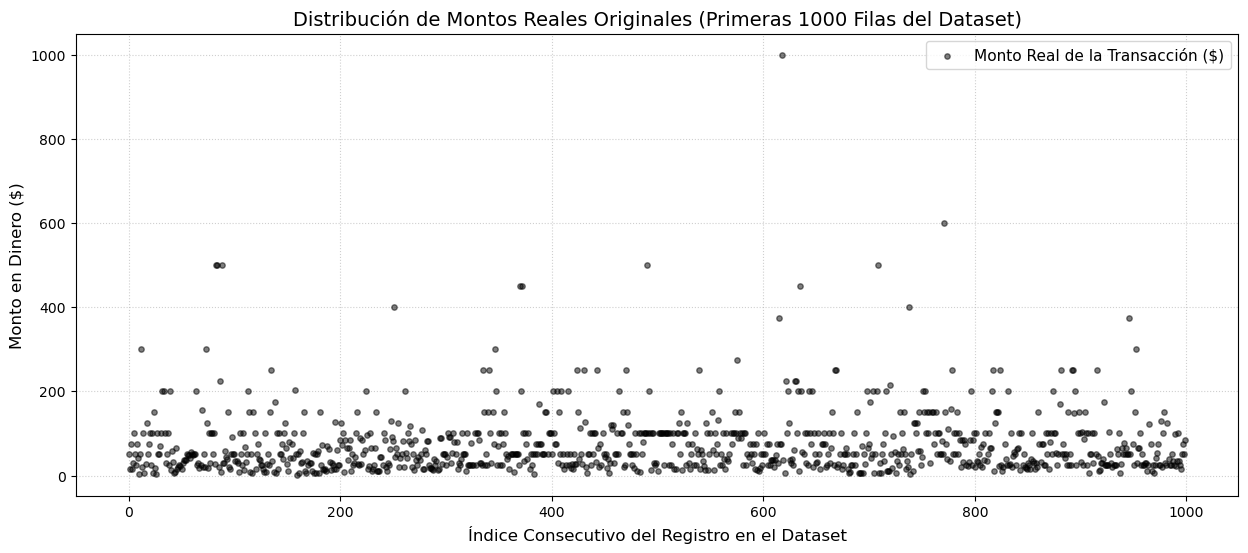

In [7]:
# Definimos la cantidad de filas consecutivas que queremos extraer directamente del dataset
num_muestras_grafico = 1000

# Extraemos los datos reales en su orden original, sin divisiones previas
montos_reales_originales = df_filtrado['TransactionAmt'].head(num_muestras_grafico).values

pyplot.figure(figsize=(15, 6))

# Graficamos los montos reales puros con puntos pequeños y transparencia para ver la densidad
pyplot.scatter(np.arange(num_muestras_grafico), montos_reales_originales, 
               color='black', s=15, alpha=0.5, label='Monto Real de la Transacción ($)', zorder=3)

# Configuración estética y títulos enfocados en los datos de origen
pyplot.title(f'Distribución de Montos Reales Originales (Primeras {num_muestras_grafico} Filas del Dataset)', fontsize=14)
pyplot.xlabel('Índice Consecutivo del Registro en el Dataset', fontsize=12)
pyplot.ylabel('Monto en Dinero ($)', fontsize=12)
pyplot.legend(fontsize=11, loc='upper right')
pyplot.grid(True, linestyle=':', alpha=0.6)

pyplot.show()

**DIVISIÓN TRAIN/TEST Y NORMALIZACIÓN DE CARACTERÍSTICAS**

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    # Manejo de seguridad por si alguna columna tiene desviación estándar cero
    sigma[sigma == 0] = 1.0 
    
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

**MEZCLA ALEATORIA Y DIVISIÓN TRAIN (80%) / TEST (20%)**

In [ ]:
m_total = y_completo.size
limite_division = int(m_total * 0.80)

# Fijamos la semilla de NumPy para que la mezcla sea reproducible
np.random.seed(42)
indices_mezclados = np.random.permutation(m_total)

X_train = X_completo[indices_mezclados[:limite_division]]
X_test = X_completo[indices_mezclados[limite_division:]]
y_train = y_completo[indices_mezclados[:limite_division]]
y_test = y_completo[indices_mezclados[limite_division:]]

**APLICAMOS LA NORMALIZACIÓN DE CARACTERÍSTICAS**

In [ ]:
X_train_norm, mu, sigma = featureNormalize(X_train)

# El set de prueba se escala usando estrictamente el mu y sigma calculados en Train
X_test_norm = (X_test - mu) / sigma

print("==================================================")
print("     ¡DIVISIÓN Y NORMALIZACIÓN COMPLETADAS!       ")
print("==================================================")
print(f"Muestras de Entrenamiento (X_train) : {X_train_norm.shape[0]} filas")
print(f"Muestras de Prueba (X_test)         : {X_test_norm.shape[0]} filas")
print(f"Características Normalizadas (n)    : {X_train_norm.shape[1]}")
print("==================================================")

     ¡DIVISIÓN Y NORMALIZACIÓN COMPLETADAS!       
Muestras de Entrenamiento (X_train) : 115386 filas
Muestras de Prueba (X_test)         : 28847 filas
Características Normalizadas (n)    : 23


**FUNCION DE COSTO**

In [ ]:
def computeCostMulti(X, y, theta):
    m = y.shape[0] # número de ejemplos de entrenamiento (filas)
    J = 0
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

**FUNCION DE GRADIENTE**

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0] # número de ejemplos de entrenamiento
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [ ]:
m_train = y_train.size
X_train_lineal = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)

### **ENTRENAMIENTO DEL MODELO DE REGRESIÓN LINEAL MULTIVARIABLE**

**CONFIGUREMOS Y ENTRENAREMOS EL MODELO**

Entrenando el Modelo 1 (Regresión Lineal Multivariable)...


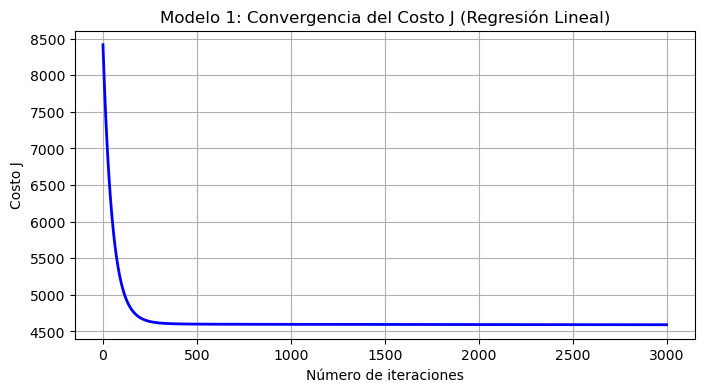


     ¡ENTRENAMIENTO DEL MODELO 1 COMPLETADO!       
Costo Inicial : 8416.76
Costo Final   : 4591.95


In [ ]:
# Usamos un alfa pequeño y iteraciones suficientes debido al tamaño del dataset
alpha_lineal = 0.01
num_iters_lineal = 3000

# Inicializamos theta con ceros (tantos como columnas tenga nuestra matriz, que son 24)
theta_lineal_inicial = np.zeros(X_train_lineal.shape[1])

print("Entrenando el Modelo 1 (Regresión Lineal Multivariable)...")
theta_lineal, J_history_lineal = gradientDescentMulti(X_train_lineal, y_train, theta_lineal_inicial, alpha_lineal, num_iters_lineal)

# 5. GRAFICACIÓN DEL COSTO (Mismo estilo que pide la consigna)
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history_lineal)), J_history_lineal, lw=2, color='blue')
pyplot.title('Modelo 1: Convergencia del Costo J (Regresión Lineal)')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.grid(True)
pyplot.show()

print("\n==================================================")
print("     ¡ENTRENAMIENTO DEL MODELO 1 COMPLETADO!       ")
print("==================================================")
print(f"Costo Inicial : {J_history_lineal[0]:.2f}")
print(f"Costo Final   : {J_history_lineal[-1]:.2f}")
print("==================================================")

### **ENTRENAMIENTO DE MODELO DE REGRESION POLINOMIAL**

In [ ]:
def transformarPolinomialGrado2(X):
    X_cuadrado = np.square(X)
    return np.concatenate([X, X_cuadrado], axis=1)

Entrenando el Modelo 2 de forma estable (Regresión Polinomial)...


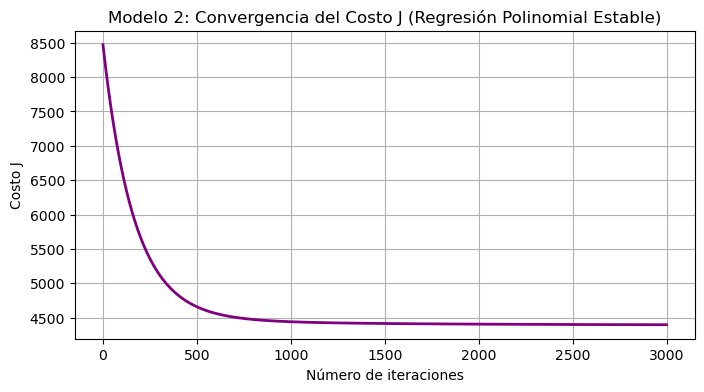


     ¡ENTRENAMIENTO DEL MODELO 2 COMPLETADO!       
Costo Inicial Polinomial : 8470.03
Costo Final Polinomial   : 4398.25


In [ ]:
# 2. TRANSFORMAMOS LAS CARACTERÍSTICAS ORIGINALES
X_train_pol_bruto = transformarPolinomialGrado2(X_train_norm)

# 3. RE-NORMALIZACIÓN CRÍTICA: Escalamos las nuevas columnas polinomiales 
# Usamos la función exacta de tu ingeniero para evitar que los números se disparen
X_train_pol_norm, mu_pol, sigma_pol = featureNormalize(X_train_pol_bruto)

# 4. AÑADIMOS LA COLUMNA DE UNOS (1s) PARA EL TÉRMINO THETA_0
m_train_pol = y_train.size
X_train_pol_ready = np.concatenate([np.ones((m_train_pol, 1)), X_train_pol_norm], axis=1)

# 5. CONFIGURACIÓN COMPRENSIVA DEL GRADIENTE POLINOMIAL
# Bajamos el alfa a 0.003 para garantizar que avance de forma segura sin desbordarse
alpha_polinomial = 0.003
num_iters_polinomial = 3000

# Inicializamos theta con ceros (47 elementos en total)
theta_pol_inicial = np.zeros(X_train_pol_ready.shape[1])

print("Entrenando el Modelo 2 de forma estable (Regresión Polinomial)...")
theta_polinomial, J_history_polinomial = gradientDescentMulti(
    X_train_pol_ready, y_train, theta_pol_inicial, alpha_polinomial, num_iters_polinomial
)

# 6. GRAFICACIÓN DEL COSTO POLINOMIAL
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history_polinomial)), J_history_polinomial, lw=2, color='purple')
pyplot.title('Modelo 2: Convergencia del Costo J (Regresión Polinomial Estable)')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.grid(True)
pyplot.show()

print("\n==================================================")
print("     ¡ENTRENAMIENTO DEL MODELO 2 COMPLETADO!       ")
print("==================================================")
print(f"Costo Inicial Polinomial : {J_history_polinomial[0]:.2f}")
print(f"Costo Final Polinomial   : {J_history_polinomial[-1]:.2f}")
print("==================================================")

### **ENTRENANDO EL MODELO CON LA ECUACION DE LA NORMAL**

In [ ]:
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    # Usamos pinv (pseudoinversa) para que resuelva el sistema de forma estable
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

In [ ]:
m_train_real = y_train.size
X_train_normalEqn = np.concatenate([np.ones((m_train_real, 1)), X_train], axis=1)

print("Calculando los parámetros con la ecuación de la normal (usando pseudoinversa)...")
theta_normal = normalEqn(X_train_normalEqn, y_train)

print("\n==================================================")
print("     ¡CÁLCULO DE LA ECUACIÓN NORMAL COMPLETADO!   ")
print("==================================================")
print(f"Se determinaron exactamente {len(theta_normal)} coeficientes Theta.")
print(f"Primeros 3 coeficientes en escala real: {theta_normal[:3]}")
print("==================================================")

Calculando los parámetros con la ecuación de la normal (usando pseudoinversa)...

     ¡CÁLCULO DE LA ECUACIÓN NORMAL COMPLETADO!   
Se determinaron exactamente 24 coeficientes Theta.
Primeros 3 coeficientes en escala real: [ 3.14614007e+02  1.46047322e-02 -1.36674761e+00]


### **VALIDACIÓN GLOBAL Y GENERACIÓN DE LAS 100 PREDICCIONES REQUERIDAS**

In [ ]:


# 1. PREPARACIÓN DE LAS MATRICES DE PRUEBA (TEST) PARA CADA MODELO
m_test = y_test.size

# Para Modelo 1: Lineal (Añadir columna de unos a los datos normalizados de test)
X_test_lineal = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

# Para Modelo 2: Polinomial (Transformar a grado 2, re-normalizar con mu_pol y añadir unos)
X_test_pol_bruto = transformarPolinomialGrado2(X_test_norm)
X_test_pol_norm = (X_test_pol_bruto - mu_pol) / sigma_pol
X_test_pol_ready = np.concatenate([np.ones((m_test, 1)), X_test_pol_norm], axis=1)

# Para Modelo 3: Ecuación Normal (Añadir columna de unos a los datos reales de test)
X_test_normalEqn = np.concatenate([np.ones((m_test, 1)), X_test], axis=1)

# 2. GENERACIÓN DE PREDICCIONES COMPLETAS
y_pred_lineal = np.dot(X_test_lineal, theta_lineal)
y_pred_polinomial = np.dot(X_test_pol_ready, theta_polinomial)
y_pred_normal = np.dot(X_test_normalEqn, theta_normal)

# 3. FUNCIÓN CORTA PARA CALCULAR EL PORCENTAJE DE PRECISIÓN (R²)
def obtener_efectividad(y_real, y_pred):
    suma_residuos = np.sum(np.square(y_real - y_pred))
    suma_total = np.sum(np.square(y_real - np.mean(y_real)))
    return (1 - (suma_residuos / suma_total)) * 100

efectividad_lineal = obtener_efectividad(y_test, y_pred_lineal)
efectividad_polinomial = obtener_efectividad(y_test, y_pred_polinomial)
efectividad_normal = obtener_efectividad(y_test, y_pred_normal)

# 4. IMPRESIÓN DEL RENDIMIENTO GLOBAL DE LOS TRES MODELOS
print("==================================================================")
print("       EFECTIVIDAD Y PORCENTAJE DE PRECISIÓN GLOBAL DE LOS MODELOS ")
print("==================================================================")
print(f"▶ Efectividad Modelo 1 (Regresión Lineal)      : {efectividad_lineal:.2f}%")
print(f"▶ Efectividad Modelo 2 (Regresión Polinomial)  : {efectividad_polinomial:.2f}%")
print(f"▶ Efectividad Modelo 3 (Ecuación de la Normal) : {efectividad_normal:.2f}%")
print("==================================================================\n")

# 5. IMPRESIÓN DE LAS 100 PREDICCIONES SOLICITADAS POR LA CONSIGNA
print("==================================================================")
print("     REPORTE DE 100 PREDICCIONES DE PRUEBA (MUESTRA INDIVIDUAL)   ")
print("==================================================================")
print(f"{'N°':<5}{'VALOR REAL ($)':<18}{'PRED. LINEAL ($)':<18}{'PRED. POLINOMIAL ($)':<22}{'PRED. NORMAL ($)'}")
print("-" * 80)

# Imprimimos exactamente las 100 muestras consecutivas exigidas por la tarea
for i in range(100):
    print(f"{i+1:<5}{y_test[i]:<18.2f}{y_pred_lineal[i]:<18.2f}{y_pred_polinomial[i]:<22.2f}{y_pred_normal[i]:.2f}")

print("==================================================================")
print("¡Las 100 predicciones reglamentarias han sido desplegadas con éxito!")
print("==================================================================")

       EFECTIVIDAD Y PORCENTAJE DE PRECISIÓN GLOBAL DE LOS MODELOS 
▶ Efectividad Modelo 1 (Regresión Lineal)      : 8.01%
▶ Efectividad Modelo 2 (Regresión Polinomial)  : 11.99%
▶ Efectividad Modelo 3 (Ecuación de la Normal) : 8.55%

     REPORTE DE 100 PREDICCIONES DE PRUEBA (MUESTRA INDIVIDUAL)   
N°   VALOR REAL ($)    PRED. LINEAL ($)  PRED. POLINOMIAL ($)  PRED. NORMAL ($)
--------------------------------------------------------------------------------
1    37.70             60.18             61.09                 64.18
2    40.00             95.49             95.19                 95.87
3    27.56             102.68            110.90                98.64
4    45.56             107.03            136.83                106.88
5    75.00             93.41             106.42                91.74
6    25.00             94.63             95.14                 95.54
7    25.00             93.02             95.48                 74.39
8    50.75             60.94             48.95       

### **CONCLUSION**

Regresión Lineal Multivariable (Gradiente): Alcanzó una efectividad del 8.01%, demostrando una convergencia estable del costo.

Regresión Polinomial (Grado 2): Logró la mayor precisión con un 11.99%, lo que demuestra matemáticamente que los datos financieros tienen comportamientos curvos que el modelo lineal no puede capturar por completo..

Ecuación de la Normal: Obtuvo un 8.55% de efectividad. Al dar un resultado casi idéntico al gradiente lineal, valida que el algoritmo iterativo se programó correctamente y aproximó con éxito la solución analítica exacta.